In [25]:
from torch.utils.data import Dataset, DataLoader
import os
import pandas as pd
import numpy as np
from PIL import Image
from torchvision import transforms
from sklearn.model_selection import train_test_split
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch as t
import sklearn as skl

print("Select GPU Backend:")
print("1: AMD (DirectML)")
print("2: NVIDIA (CUDA)")
print("3: CPU")

Select GPU Backend:
1: AMD (DirectML)
2: NVIDIA (CUDA)
3: CPU


In [27]:
import sys
from pathlib import Path
SCRIPT_DIR = Path.cwd()
ROOT_DIR = SCRIPT_DIR.parent
sys.path.append(str(ROOT_DIR))
import pandas as pd
import numpy as np
from tqdm import tqdm
from data.datasets import set_seed

### Check data

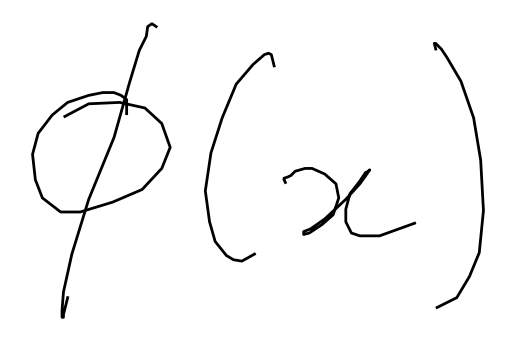

In [28]:
raw_image = Image.open("../img_data/inkML_data_CROHME_training_2011_formulaire001-equation001.inkml_0.png").convert('RGB')
raw_image

In [29]:
# Load BASE model for extremely fast Proof of Concept (PoC)
hf_model_id = "microsoft/trocr-base-handwritten"
device = t.device("cpu")
model = VisionEncoderDecoderModel.from_pretrained(hf_model_id, use_safetensors=True).to(
    device
)
processor = TrOCRProcessor.from_pretrained(hf_model_id)


Loading weights: 100%|██████████| 478/478 [00:00<00:00, 9130.68it/s]
VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [30]:
class AddGaussianNoise(object):
    def __init__(self, mean=0.0, std=0.05):
        self.std = std
        self.mean = mean

    def __call__(self, tensor):
        return tensor + t.randn(tensor.size()).to(tensor.device) * self.std + self.mean

    def __repr__(self):
        return self.__class__.__name__ + "(mean={0}, std={1})".format(
            self.mean, self.std
        )

In [32]:
class MathCaptionsDataset(Dataset):
    """
    A dataset object that loads in images from img_data and captions from labels.csv.

    - Processor: A Huggingface processor object that will be used to process the images and captions.
    - img_dir: The directory containing the images and labels.csv.
    - csv_file: The file containing the captions.
    - transform: A torchvision transform to be applied to the images.
    """

    def __init__(
        self,
        processor,
        img_dir=os.path.join(ROOT_DIR, "img_data"),
        csv_file="labels.csv",
        transform=None,
        use_float16=False,
        device=device,
        partition="train",
        test_split=0.2,
        random_seed=0,
    ):

        self.img_dir = img_dir
        self.csv_path = os.path.join(img_dir, csv_file)
        self.labels = pd.read_csv(self.csv_path)
        # Randomly select data_split of the data for training and the rest for validation
        self.labels, self.labels_val = train_test_split(
            self.labels, test_size=test_split, random_state=random_seed
        )
        self.partition = partition
        self.transform = transform
        self.processor = processor
        self.use_float16 = use_float16
        self.device = device

    def __len__(self):
        if self.partition == "train":
            return len(self.labels)
        else:
            return len(self.labels_val)

    def train(self):
        self.partition = "train"

    def val(self):
        self.partition = "val"

    def __getitem__(self, idx):
        if t.is_tensor(idx):
            idx = idx.tolist()

        if self.partition == "train":
            img_name = os.path.join(self.img_dir, self.labels.iloc[idx, 1])
        else:
            img_name = os.path.join(self.img_dir, self.labels_val.iloc[idx, 1])

        image = Image.open(img_name).convert("RGB")

        # Apply data augmentation only for training
        if self.partition == "train" and self.transform is not None:
            image = self.transform(image)

        # Process image - keep on CPU during dataset fetch to avoid per-item GPU overhead
        inputs = self.processor(images=image, padding="max_length", return_tensors="pt")
        for key in inputs:
            inputs[key] = inputs[key].squeeze()

        if self.partition == "train":
            caption = self.labels.iloc[idx, 0]
        else:
            caption = self.labels_val.iloc[idx, 0]
        caption = (
            self.processor.tokenizer.encode(
                caption,
                return_tensors="pt",
                padding="max_length",
                max_length=256,  # Tweak this, longest length in current dataset is 156
            )
            .to(self.device)
            .squeeze()
        )

        return inputs, caption

#### Pre-Process data

In [33]:
# Load LST files
import os
import sys
from pathlib import Path
import pandas as pd
from PIL import Image
from tqdm import tqdm
sys.path.append(os.path.abspath("../"))
from utils.latex import crop_to_formula, renderedLaTeXLabelstr2Formula, display_formula
ROOT = Path("..")
train_lst = ROOT / "rendered_LaTeX" / "im2latex_train.lst"
val_lst = ROOT / "rendered_LaTeX" / "im2latex_validate.lst"
formulas_lst = ROOT / "rendered_LaTeX" / "im2latex_formulas.lst"
formula_images_dir = ROOT / "formula_images"
train_filenames_df = pd.read_csv(
    train_lst,
    sep=" ",
    index_col=0,
    header=None,
)
val_filenames_df = pd.read_csv(
    val_lst,
    sep=" ",
    index_col=0,
    header=None,
)
with open(formulas_lst, encoding="ISO-8859-1", newline="\n") as f:
    formulas = [line.rstrip("\n") for line in f]
def find_invalid_formula_ids(filenames_df, image_dir):
    invalid_formula_ids = []
    for formula_id in tqdm(filenames_df.index):
        image_name = filenames_df.loc[formula_id, 1]
        image_path = image_dir / f"{image_name}.png"
        try:
            formula_image = Image.open(image_path).convert("RGBA")
            crop_to_formula(formula_image)
        except Exception:
            invalid_formula_ids.append(formula_id)
    return invalid_formula_ids
invalid_train_ids = find_invalid_formula_ids(train_filenames_df, formula_images_dir)
print("Invalid train images:", len(invalid_train_ids))
train_filenames_df = train_filenames_df.drop(index=invalid_train_ids)
invalid_val_ids = find_invalid_formula_ids(val_filenames_df, formula_images_dir)
print("Invalid val images:", len(invalid_val_ids))
val_filenames_df = val_filenames_df.drop(index=invalid_val_ids)
valid_formula_ids = sorted(set(train_filenames_df.index) | set(val_filenames_df.index))
filtered_formulas = [formulas[formula_id] for formula_id in valid_formula_ids]
print("Number of training formulas:", len(train_filenames_df))
print("Number of validation formulas:", len(val_filenames_df))
max_len = max(len(formula) for formula in filtered_formulas)
print("Max length:", max_len)

 21%|██        | 17309/83884 [09:15<35:35, 31.17it/s]  


KeyboardInterrupt: 

In [34]:
import torch as t
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm, trange

# Hyperparams - Optimized for extremely fast Proof of Concept (PoC)
NUM_EPOCHS = 1
LEARNING_RATE = 1e-5
BATCH_SIZE = 2  # Very safe for VRAM
SHUFFLE_DATASET = True

# Define Augmentation Transform - Simplified for better CPU performance
train_transforms = transforms.Compose(
    [
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.RandomAffine(degrees=2, translate=(0.01, 0.01)),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    ]
)

set_seed(0)
optimizer = t.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
train_ds = MathCaptionsDataset(processor, transform=train_transforms)
train_ds.train()
train_dl = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=SHUFFLE_DATASET, num_workers=0
)
val_ds = MathCaptionsDataset(processor)
val_ds.val()
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
assert (train_ds.labels_val.values == val_ds.labels_val.values).all()

model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.to(device)
model.train()

history = []
val_history = []
val_timesteps = []
ema_loss = None
ema_alpha = 0.95
scaler = t.cuda.amp.GradScaler(enabled=True)
for epoch in range(NUM_EPOCHS):
    with tqdm(train_dl, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}") as pbar:
        for batch, captions in pbar:
            # Move batch to device here (more efficient for some backends)
            pixel_values = batch["pixel_values"].to(device)
            captions = captions.to(device)

            optimizer.zero_grad()
            # AMP (Autocast) works best on NVIDIA, but we'll leave it or disable if on DirectML
            autocast_enabled = device.type == "cuda"
            with t.autocast(
                device_type="cuda" if device.type == "cuda" else "cpu",
                enabled=autocast_enabled,
            ):
                outputs = model(pixel_values=pixel_values, labels=captions)
                loss = outputs.loss
                history.append(loss.item())
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            if ema_loss is None:
                ema_loss = loss.item()
            else:
                ema_loss = ema_loss * ema_alpha + loss.item() * (1 - ema_alpha)
            pbar.set_postfix(loss=ema_loss)

            # Explicitly delete tensors to help with memory reclamation
            del pixel_values, captions, outputs, loss

    model.eval()
    with t.no_grad():
        val_losses = []
        for batch, captions in tqdm(val_dl):
            pixel_values = batch["pixel_values"]
            outputs = model(pixel_values=pixel_values, labels=captions)
            val_losses.append(outputs.loss.item())
        print(f"Validation loss: {np.mean(val_losses)}")
        val_history.append(np.mean(val_losses))
        val_timesteps.append(len(history) - 1)

output_dir = os.path.join(ROOT_DIR, "models", "trocr-large-finetuned-math-captions")
os.makedirs(output_dir, exist_ok=True)

import json

model.save_pretrained(output_dir)
processor.save_pretrained(output_dir)

# Save history as JSON instead of torch.save to avoid security blocks
with open(os.path.join(output_dir, "history.json"), "w") as f:
    json.dump(history, f)
with open(os.path.join(output_dir, "val_history.json"), "w") as f:
    json.dump(val_history, f)
with open(os.path.join(output_dir, "val_timesteps.json"), "w") as f:
    json.dump(val_timesteps, f)

/var/folders/8j/57djmdxx5dnby2m0lx0xrl540000gn/T/ipykernel_78546/3352533796.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = t.cuda.amp.GradScaler(enabled=True)
/Users/hoangnguyen/Downloads/personal/handwriting-HGF/.venv/lib/python3.12/site-packages/torch/amp/grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
Epoch 1/1:   0%|          | 1/4437 [00:10<13:05:18, 10.62s/it, loss=17.9]


KeyboardInterrupt: 

In [40]:
# Save the processed data
train_filenames_df = pd.read_csv("../rendered_LaTeX/processed_im2latex_train.lst", index_col = 0, header = None, sep = " ")
val_filenames_df = pd.read_csv("../rendered_LaTeX/processed_im2latex_val.lst", index_col = 0, header = None, sep = " ")
formulas = open("../rendered_LaTeX/im2latex_formulas.lst", encoding = "ISO-8859-1", newline="\n").readlines()

In [41]:
import copy
cached_train_filenames_df = copy.deepcopy(train_filenames_df)
cached_val_filenames_df = copy.deepcopy(val_filenames_df)

#### Training:

In [42]:
# Load LST files
import pandas as pd
import numpy as np
import re
from tqdm import tqdm, trange

import sys, os
sys.path.append(os.path.abspath('../'))
from utils.latex import crop_to_formula, renderedLaTeXLabelstr2Formula, display_formula

train_filenames_df = pd.read_csv("../rendered_LaTeX/processed_im2latex_train.lst", index_col = 0, header = None, sep = " ")
val_filenames_df = pd.read_csv("../rendered_LaTeX/processed_im2latex_val.lst", index_col = 0, header = None, sep = " ")
formulas = open("../rendered_LaTeX/im2latex_formulas.lst", encoding = "ISO-8859-1", newline="\n").readlines()

print("Number of training formulas: ", len(train_filenames_df))
print("Number of validation formulas: ", len(val_filenames_df))

max_len = max([len(formula) for formula in formulas])
print("Max length:", max_len)

Number of training formulas:  83884
Number of validation formulas:  9320
Max length: 998


### Testing using random image 1

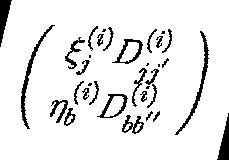

Formula: \left( \begin{array}{c}                                      {\xi}^{(i)}_{j}D^{(i)}_{jj^{'}}\\                                       {\eta}^{(i)}_{b}D^{(i)}_{bb^{''}}                                     \end{array}                                     \right)

\left( \begin{array}{c}                                      {\xi}^{(i)}_{j}D^{(i)}_{jj^{'}}\\                                       {\eta}^{(i)}_{b}D^{(i)}_{bb^{''}}                                     \end{array}                                     \right)



In [43]:
import torchvision.transforms as transforms
import torchvision.transforms.v2
train_transforms = transforms.Compose([
    transforms.v2.RandomAffine(degrees=5,
                             scale=(0.7, 1.1),
                             shear=30),
    transforms.v2.ColorJitter(brightness=0.3,
                            contrast=0.3,
                            saturation=0.3,
                            hue=0.2),
    transforms.v2.RandomInvert(p=0.3),
    transforms.v2.RandomGrayscale(p=0.1),
    transforms.v2.RandomPosterize(bits=2, p=0.1),
])
random_idx = np.random.choice(train_filenames_df.index)
formula_image_example = Image.open("../formula_images/" + train_filenames_df.loc[random_idx, 1] + ".png").convert('RGBA')

from IPython.display import display, Math, Latex

display(train_transforms(crop_to_formula(formula_image_example)))
display_formula(renderedLaTeXLabelstr2Formula(formulas[random_idx]))
print(renderedLaTeXLabelstr2Formula(formulas[random_idx]))

#### Testing Results using random image 2

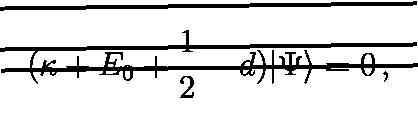

<IPython.core.display.Math object>

(\kappa+E_0+\frac{1}{2}-d)|\Psi\rangle=0,



<IPython.core.display.Math object>

(\kappa + E_0 + \frac{1}{2} - d) |\Psi \rangle = 0,



In [18]:
random_idx = np.random.choice(val_filenames_df.index)
formula_image_example = Image.open("../formula_images/" + val_filenames_df.loc[random_idx, 1] + ".png").convert('RGBA')

display(crop_to_formula(formula_image_example))
from IPython.display import display, Math, Latex
display_formula(renderedLaTeXLabelstr2Formula(formulas[random_idx]))
print(renderedLaTeXLabelstr2Formula(formulas[random_idx]))

model_prediction = model.generate(processor(images = crop_to_formula(formula_image_example), return_tensors="pt").pixel_values.to(device), max_new_tokens = 512)
str_pred = processor.batch_decode(model_prediction, skip_special_tokens=True)[0]
display_formula(str_pred)
print(str_pred)